In [1]:
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_config_filepath, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import os

#Pyörittelyt --------------------------------------------------------

In [2]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config6.json")

In [3]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [3]:
QReservoir_models = []

for i in range(n_models):
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    Qres = QReservoir.init_from_file(systempath)
    QReservoir_models.append(Qres)

In [4]:
test_inputs_sq_th = np.array([gen_input_states("sq_th", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_add = np.array([gen_input_states("pho_add", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_sub = np.array([gen_input_states("pho_sub", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_simple = np.array([gen_input_states("simple", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

In [5]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999859999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000113554+0j)
tr_res: (1+0j)
tr_new: (1.000000050224+0j)
tr_res: (1+0j)
tr_new: (1.0000000073909998+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999971996+0j)
tr_res: (1+0j)
tr_new: (1.000000005525+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999701420001+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999919843+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998639629999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999893769+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999904945+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997577830001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997633800001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.99999970191+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997019200002+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996683779999+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999655349+0j)
tr_res: (0.9999

In [7]:
QReservoir_models[7] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_inputs[7] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)

QReservoir_models[7].init_reservoir("vacuum")
QReservoir_models[7].rk4_timesteps(4)

In [9]:
QReservoir_models[7].train_reservoir(train_inputs[7])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 7)
QReservoir_models[7].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.999999999988+0j)
0
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998597469999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998102050001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996454169999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995779640001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995217850001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995794130001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995654739999+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994804679999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999564541+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995387629999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999578955+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999669995+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996601269999+0j)
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999611612+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994765600001+0j)
tr_res: (0.99

In [6]:
resultpath = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity))

In [16]:
res = QReservoir_models[0].analyze_performance(QReservoir_models[0].test_Y_true, QReservoir_models[0].test_Y_pred)
write_to_row(str(res), resultpath)

In [7]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_th[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (0.9999982714653015+0j)
tr_new: (0.9999982211099999+0j)
0
tr_res: (0.9999982714653015+0j)
tr_new: (0.9999982676760001+0j)
tr_res: (0.9999982714653015+0j)
tr_new: (0.9999983123770001+0j)
tr_res: (0.9999983310699463+0j)
tr_new: (0.9999982956150001+0j)
tr_res: (0.9999983906745911+0j)
tr_new: (0.999998396192+0j)
tr_res: (0.9999985098838806+0j)
tr_new: (0.9999985023660002+0j)
tr_res: (0.9999985694885254+0j)
tr_new: (0.9999985917769999+0j)
tr_res: (0.9999985098838806+0j)
tr_new: (0.9999985042309999+0j)
tr_res: (0.9999985694885254+0j)
tr_new: (0.999998548933+0j)
tr_res: (0.9999987483024597+0j)
tr_new: (0.9999987352019998+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988488210001+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987650089998+0j)
tr_res: (0.9999987483024597+0j)
tr_new: (0.999998761269+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.9999989270599999+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.9999989140109999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.999998858

In [18]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_add[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987994309999+0j)
0
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987997840001+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.999998913113+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988709149998+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998819341+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998754149+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987649759999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987779520001+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987799319999+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.999998663196+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.9999987252179999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.99999883791+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988382889999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988276009999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.999998847277+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988849120001+0j)


KeyboardInterrupt: 

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_sub[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_simple[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

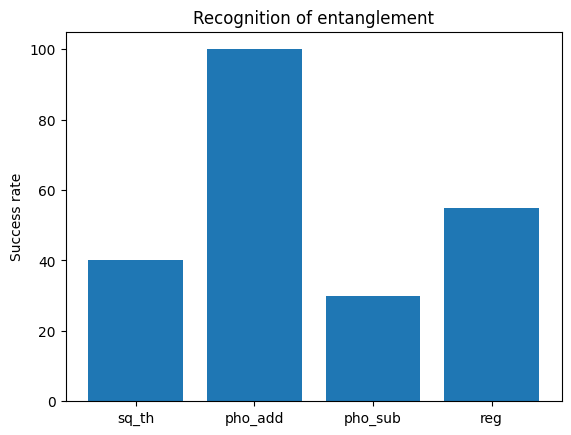

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [8]:
from tools import *

In [6]:
train_in = gen_input_states("ST", 20, fock_truncation, sim_rounding)

test_pho_add = gen_input_states("PASV", 100, 5)
test_pho_sub = gen_input_states("PSSV", 100, 5)
test_simple = gen_input_states("simple", 100, 5)
test_sq_th = gen_input_states("ST",100, 5)

In [10]:
jes = get_entanglement_values(train_in, "first", 5,5,2)


In [17]:
5%2==0

False

In [14]:
np.array([*[[1,0] for _ in range(10)], *[[0,1] for _ in range(10)]])

array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1]])

In [4]:
Qres1 = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
Qres1.init_reservoir("vacuum")
Qres1.rk4_timesteps(4)

In [9]:
Qres1.train_reservoir(train_in)

tr_res: (1+0j)
tr_new: (0.99999999999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000006256+0j)
tr_res: (1+0j)
tr_new: (1.000000016474+0j)
tr_res: (1+0j)
tr_new: (1.000000031781+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000827039999+0j)
tr_res: (1+0j)
tr_new: (1.000000031157+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000092539+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000201162+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000122081+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999883691+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999896657+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.9999998775910001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999996913350001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999709024+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999662833+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999996969010001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997459780001+0j)
tr_res: (0.9999997019767761+

In [10]:
result = Qres1.test_reservoir(test_simple)


tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997615814209-3.2760003598752974e-09j)
0
tr_res: (0.9999997615814209-3.2629998703015417e-09j)
tr_new: (0.9999997615814209-9.457999716744325e-09j)
tr_res: (0.9999997019767761-9.45999989454549e-09j)
tr_new: (0.9999998211860657-1.0814999562569483e-08j)
tr_res: (0.9999997019767761-1.0842000186528367e-08j)
tr_new: (0.9999998211860657-1.0906001435273538e-08j)
tr_res: (0.9999997615814209-1.0909999126340608e-08j)
tr_new: (0.9999997615814209-1.9815999507954984e-08j)
tr_res: (0.9999998211860657-1.980099995080309e-08j)
tr_new: (0.9999997615814209-2.3876999932781473e-08j)
tr_res: (0.9999998211860657-2.3873999666079726e-08j)
tr_new: (0.9999998211860657-2.3475999810784742e-08j)
tr_res: (0.9999997615814209-2.3509999280690863e-08j)
tr_new: (0.9999996423721313-2.1019001650302016e-08j)
tr_res: (0.9999996423721313-2.1036001385255076e-08j)
tr_new: (0.9999996423721313-2.3687999117782965e-08j)
tr_res: (0.9999995827674866-2.368099849547889e-08j)
tr_new: (0.999999

In [ ]:

import scipy as sp
import qutip as qt

In [4]:
def get_entanglement_values(inputs):
    return np.array([[1,0] if assess_dm_entanglement(input, "first", fock_truncation, fock_truncation, 2) > 0 else [0,1] for input in inputs])

In [28]:
focks = 10
sum = 0
enta = 0
for input in test_sq_th10:
    ent = assess_dm_entanglement(input, "first", focks, focks, 5)
    sum += ent
    if ent < 0.005:
        enta +=1
    print(ent)

print()
print(enta)
print()

print(sum/100)

0.44858
0.77294
0.18974
0.37846
0.81176
0.87753
0.68596
0.15462
0.33264
1.03954
0.4255
0.62549
0.0
0.98532
0.83678
0.13878
0.46329
0.0
0.0
0.0
0.11224
4e-05
0.00093
0.00021
0.33811
8e-05
0.58423
2e-05
0.78694
0.54147
0.05085
0.0
0.38074
3e-05
0.77079
0.0
0.00025
0.07371
0.52384
0.00018
0.0
0.87801
0.0
0.03049
0.00014
0.91397
0.28197
0.01154
1e-05
0.69552
0.97244
0.41917
1e-05
8e-05
0.70922
-0.0
0.01665
0.88335
0.00028
0.17308
0.14349
0.52168
0.36303
-0.0
0.3901
0.54223
0.88466
0.79348
0.79259
0.0
0.90431
0.00016
0.17374
0.97155
9e-05
0.0
0.71677
0.0
0.00032
0.0
1e-05
0.35527
0.00053
0.0
0.0
1e-05
0.64235
2e-05
0.0
0.0
0.39655
0.34686
5e-05
0.41484
1e-05
0.0
0.0
0.0
0.0
0.0

45

0.2867222


In [29]:

for i,j in enumerate([test_simple5,test_simple6,test_simple7,test_simple8,test_simple9,test_simple10]):
    focks = i + 5
    sum = 0
    for input in j:
        ent = assess_dm_entanglement(input, "first", focks, focks, 5)
        sum += ent
        print(ent)

    print()
    print()
    print(sum/100)


0.33091
0.65939
0.83888
0.99955
0.97053
0.95533
0.98962
0.94266
0.96259
0.87026
0.77132
0.98792
0.93786
0.59728
0.99516
0.98736
0.94983
0.98631
0.99864
0.98965
0.99983
0.30541
0.31909
0.99497
0.8467
0.6159
0.69152
0.52717
0.67482
0.92445
0.99994
0.65287
0.98918
0.99951
0.23987
0.50427
0.68023
0.95642
0.95492
0.82734
0.99729
0.73594
0.87633
0.21542
0.84842
0.87641
0.99959
0.71281
0.80495
0.35986
0.82039
0.67192
1.0
0.75894
0.95069
0.89256
0.99898
0.91626
0.94536
0.40442
0.93555
0.7713
0.84359
0.92563
0.99892
0.72845
0.99947
0.99361
0.98977
0.82329
0.987
0.96346
0.54379
0.99807
0.80823
0.8961
0.80733
0.81132
0.99442
0.85986
0.97584
0.9621
0.38115
0.65434
0.69421
0.99082
0.38423
0.74732
0.99913
0.98561
0.98751
0.96482
0.99884
0.99874
0.99156
0.69089
0.88595
0.76388
0.39375
0.93085


0.82272714
0.89883
0.67985
0.7702
0.996
0.73599
0.68483
0.87265
0.67798
0.39322
0.8219
0.80013
0.99584
0.91628
0.65639
0.99807
0.71551
0.89028
0.97918
0.5814
0.88223
0.99642
0.40358
0.99139
0.99655
0.87386
0.9

In [30]:

for i,j in enumerate([test_pho_add5,test_pho_add6,test_pho_add7,test_pho_add8,test_pho_add9,test_pho_add10]):
    focks = i + 5
    sum = 0
    for input in j:
        ent = assess_dm_entanglement(input, "first", focks, focks, 5)
        sum += ent
        print(ent)

    print()
    print()
    print(sum/100)

0.85972
0.89414
1.05207
0.59397
1.21218
0.71168
0.60623
1.21597
0.76402
0.55126
0.90389
1.00496
0.57808
0.61871
1.13031
0.78633
0.78313
0.81735
0.57657
0.81336
0.82279
0.76628
0.55135
0.7482
0.90639
1.16068
1.05621
1.05108
0.72401
0.84077
0.78142
0.94902
0.82991
1.15936
1.06571
1.19215
0.68525
0.7227
1.07534
0.9571
0.9082
0.73252
1.05892
0.83529
0.88417
0.69054
0.91854
1.21121
0.96143
0.98079
0.9474
0.89216
1.09925
1.01562
0.78997
0.93854
0.69
1.13422
1.15266
1.05051
0.90443
0.84118
1.168
0.90224
0.75665
1.22564
0.83132
0.81626
0.7462
0.56556
0.9922
1.03155
0.93602
0.94991
0.80328
0.54928
0.91256
0.79691
0.67062
1.12161
0.93137
1.19346
1.10722
0.65221
1.2171
0.98016
1.15602
0.6156
0.97878
0.58864
1.22545
1.13384
0.72717
0.6533
0.66789
0.73622
0.93263
0.98348
1.08398
0.71606


0.8921358999999999
0.55969
0.60231
0.81831
0.9477
0.67088
0.84595
1.23644
1.01518
0.63333
0.84965
0.81066
0.58225
0.96811
0.74919
1.12574
1.23871
0.73367
0.60089
0.84985
1.00808
0.84763
1.18642
0.99522
0.59466
1.0

In [31]:

for i,j in enumerate([test_pho_sub5,test_pho_sub6,test_pho_sub7,test_pho_sub8,test_pho_sub9,test_pho_sub10]):
    focks = i + 5
    sum = 0
    for input in j:
        ent = assess_dm_entanglement(input, "first", focks, focks, 5)
        sum += ent
        print(ent)

    print()
    print()
    print(sum/100)

1.86839
1.78228
1.85881
1.87576
1.79979
1.90983
1.91727
1.81967
1.8273
1.90465
1.87994
1.80854
1.92928
1.79941
1.90281
1.91862
1.89723
1.88911
1.87852
1.83911
1.89647
1.83568
1.86208
1.86904
1.79891
1.9303
1.87007
1.78318
1.86317
1.858
1.91388
1.89288
1.90985
1.79471
1.93157
1.83894
1.79323
1.78514
1.92668
1.81261
1.82698
1.92468
1.89455
1.91606
1.82321
1.86723
1.82084
1.82503
1.87809
1.88931
1.81767
1.91702
1.83456
1.85514
1.81878
1.79926
1.83556
1.87387
1.82689
1.89623
1.84213
1.89951
1.90294
1.79046
1.92739
1.91277
1.82246
1.78548
1.89026
1.9029
1.8612
1.91423
1.91557
1.81652
1.85338
1.79175
1.89208
1.91044
1.80448
1.92934
1.79706
1.90278
1.82798
1.88248
1.89944
1.89741
1.87976
1.80158
1.88028
1.8947
1.81701
1.84651
1.84884
1.7938
1.86758
1.93089
1.86839
1.87581
1.92623
1.86723


1.8628472000000003
2.19792
2.23306
2.22827
2.22505
2.25039
2.27572
2.22708
2.18339
2.23344
2.26467
2.2828
2.20681
2.27864
2.20376
2.21461
2.24461
2.25438
2.21598
2.2034
2.25546
2.23169
2.18304
2.28315
2.251

In [107]:
def init_two_mode_sq(alpha, a1, a2):
    A_ = alpha * dagger(a1) @ dagger(a2) - np.conjugate(alpha) * a1 @ a2
    return sp.linalg.expm(A_)

def init_th(mean_n, truncate, other=False):
    if other:
        beta = np.log(1.0 / mean_n + 1.0)
        values_ = np.exp(-beta * np.arange(truncate))
        values_ = values_ / np.sum(values_)
    else:
        values_ = [1/(1+mean_n)*(mean_n/(1+mean_n))**x for x in np.arange(truncate)]

    return np.diag(values_)

def init_two_mode_th(mean_n, truncate):
    return tensor([init_th(mean_n, truncate, other=True), init_th(mean_n, truncate,other=True)])

def init_vac(truncate):
    vac_ = np.zeros((truncate, truncate), dtype=np.complex64)
    vac_[0,0] = 1
    return vac_

def init_sq_add(alpha, truncate, a1, a2, rounding=None):

    sq_ = init_two_mode_sq(alpha, a1, a2)
    vac_ = init_vac(truncate**2)
    sq_add_ = dagger(a1) @ dagger(a2) @ sq_ @ vac_ @ dagger(sq_) @ a2 @ a1

    #Normalize
    sq_add_ = sq_add_ / np.trace(sq_add_)

    if rounding:  
        return truncate_mantissa(sq_add_, rounding)
    
    return sq_add_

def init_sq_sub(alpha, truncate, a1, a2, rounding=None):

    sq_ = init_two_mode_sq(alpha, a1, a2)
    vac_ = init_vac(truncate**2)
    sq_sub_ = a1 @ a2 @ sq_ @ vac_ @ dagger(sq_) @ dagger(a2) @ dagger(a1)

    #Normalize
    sq_sub_ = sq_sub_ / np.trace(sq_sub_)

    if rounding:  
        return truncate_mantissa(sq_sub_, rounding)
    
    return sq_sub_

#Function that creates a two-mode squeezed thermal state
def init_sq_th(alpha, mean_n, truncate, a1, a2, rounding=None):
    
    #Initialize the two-mode thermal state
    sq_ = init_two_mode_sq(alpha, a1, a2)
    th_ = init_two_mode_th(mean_n, truncate)

    if rounding:  
        return truncate_mantissa(sq_ @ th_ @ dagger(sq_), rounding)
    
    return sq_ @ th_ @ dagger(sq_)


def init_squeeze(alpha, a):
    A_ = alpha * dagger(a) @ dagger(a) - np.conjugate(alpha) * a @ a
    return sp.linalg.expm(A_)


In [5]:
truncate = 5
amount_of_states = 10000

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])
        
theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states,))
phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states,))
alpha_sq_th_ = np.array([x*np.sin(y)*np.exp(1j*z) for x, y, z in zip(s_sq_th_,phi_sq_th_,theta_sq_th_)])
mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

abs_alpha_pho_add_ = np.random.uniform(0.1, 0.25, (amount_of_states,))
theta_pho_add_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_add_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_add_,theta_pho_add_)])  

abs_alpha_pho_sub_ = np.random.uniform(0.8, 0.95, (amount_of_states,))
theta_pho_sub_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_sub_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_sub_,theta_pho_sub_)])

theta_simple_ = np.array([np.arcsin(np.sqrt(x)) for x in np.random.uniform(0,1,(amount_of_states,))])
phi_simple_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
c0_simple_ = np.array([np.sin(x) for x in theta_simple_])
c1_simple_ = np.array([np.cos(x)*np.exp(1j*y) for x,y in zip(theta_simple_, phi_simple_)])

In [6]:
qa = qt.operators.destroy(5)
qid = qt.operators.qeye(5)

qa1 = qt.tensor(qa, qid)
qa2 = qt.tensor(qid, qa)

squeezing = init_two_mode_sq(-1/2*alpha_sq_th_[0], a1, a2)
qsqueezing = qt.operators.squeezing(qa1, qa2, alpha_sq_th_[0])

In [97]:
vac = qt.states.fock_dm(5,0)
vac = qt.tensor(vac, vac)

for i in range(25):
    squeeze1 = qt.operators.squeezing(qa1, qa2, alpha_pho_add_[i])
    squeeze2 = qt.operators.squeezing(qa1, qa2, alpha_pho_sub_[i])

    sq_vac1 = squeeze1 @ vac @ squeeze1.dag()
    sq_vac2 = squeeze2 @ vac @ squeeze2.dag()

    print(assess_dm_entanglement(sq_vac1.full(), "first", 5, 5, 5))
    print(assess_dm_entanglement(sq_vac2.full(), "first", 5, 5, 5))

    pho_add = qa1.dag() @ qa2.dag() @ sq_vac1 @ qa2 @ qa1
    pho_sub = qa1 @ qa2 @ sq_vac2 @ qa2.dag() @ qa1.dag()

    pho_add = pho_add.full() / np.trace(pho_add.full())
    pho_sub = pho_sub.full() / np.trace(pho_sub.full())
    print()
    print(assess_dm_entanglement(pho_add, "first", 5, 5, 5))
    print(assess_dm_entanglement(pho_sub, "first", 5, 5, 5))
    print()
    print()

0.32523
1.18326

0.61211
1.74433


0.28758
1.24092

0.54543
1.78952


0.16165
1.16567

0.31413
1.72971


0.29409
1.13542

0.55706
1.70363


0.20154
1.31799

0.38873
1.84316


0.25986
1.1666

0.4956
1.73049


0.18131
1.25138

0.35105
1.79725


0.18134
1.31368

0.35111
1.84036


0.32641
1.28564

0.61417
1.82159


0.24614
1.22992

0.47069
1.78123


0.2323
1.31397

0.44544
1.84055


0.26849
1.15261

0.51119
1.71859


0.33782
1.15292

0.63413
1.71886


0.17774
1.22637

0.34436
1.77852


0.35703
1.24962

0.66746
1.79596


0.15149
1.1487

0.29494
1.71522


0.25391
1.25638

0.48483
1.8009


0.20434
1.29507

0.39392
1.82802


0.16117
1.28834

0.31323
1.82344


0.21417
1.32375

0.4121
1.84685


0.17724
1.27382

0.34344
1.81336


0.24375
1.20195

0.46634
1.75945


0.24852
1.22803

0.47502
1.77979


0.17709
1.25585

0.34316
1.80051


0.16977
1.21878

0.32942
1.77268




In [ ]:
a_ = init_destroy(5)

def init_squeeze(alpha, a):
    A_ = alpha * dagger(a) @ dagger(a) - np.conjugate(alpha) * a @ a
    return sp.linalg.expm(A_)

squeeze1 = init_squeeze(alpha_pho_add_[0], a_)
squeeze2 = init_squeeze(alpha_pho_add_[1], a_)

pho_add1 = dagger(a_) @ squeeze1 @ init_vac(5) @ dagger(squeeze1) @ a_
pho_add2 = dagger(a_) @ squeeze2 @ init_vac(5) @ dagger(squeeze2) @ a_

pho_add1 = pho_add1 / np.trace(pho_add1)
pho_add2 = pho_add2 / np.trace(pho_add2)

pho_add = tensor([pho_add1, pho_add2])
np.sum(np.abs(np.linalg.eigvals((partial_transpose(test_sq_th5[1], "first", 5,5)))))
#(trace_norm(partial_transpose(pho_add, "first", 5,5))-1)/2
#assess_dm_entanglement(pho_add, "first", 5,5,5)

np.float64(1.9983176927458621)

In [19]:
perm = np.random.permutation(4)

jeps = np.array(["joo","jee","juu","jaa"])

jeps

array(['joo', 'jee', 'juu', 'jaa'], dtype='<U3')